# Time Series Analysis — Cleaning, Trend & Seasonality

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/time-series/notes.ipynb)


## 1. What makes time series data different

- **Definition**: a time series has a timestamp `t` and a value `y` at each timestamp, in order. Monthly revenue,
  daily temperature, hourly server load — all examples.
- **Order matters**: in a normal dataset, you can shuffle the rows and nothing breaks — each row still means the
  same thing on its own. In a time series, order is part of the meaning. Shuffle it, and trend and seasonality
  (both explained below) stop making sense.
- **Why this matters**: most time series methods assume every time period is present, with none skipped. A
  missing month is not just one missing row — it breaks moving averages and any method that looks back at
  "the last few months."

**Dataset for this notebook**: 16 years of made-up monthly revenue (Jan 2008 – Dec 2023) for a fictional
e-commerce brand. It's built to look like real retail data: revenue slowly grows over time, spikes every festive
season, dips a little every monsoon, and has a few missing months and a couple of data-entry mistakes mixed in.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

DATA_PATH = "data/monthly-revenue.csv"


def build_synthetic_revenue():
    rng = np.random.default_rng(7)
    dates = pd.date_range("2008-01-01", "2023-12-01", freq="MS")
    t = np.arange(len(dates))

    trend = 40_000 + 180 * t
    seasonal_shape = {1: -2000, 2: -2500, 3: -1500, 4: -500, 5: 500, 6: -1000,
                       7: -1500, 8: 0, 9: 2000, 10: 6000, 11: 8000, 12: 3000}
    seasonal = np.array([seasonal_shape[m] for m in dates.month])
    noise = rng.normal(0, 1800, len(dates))
    revenue = trend + seasonal + noise

    # A couple of one-off mistakes in the data: one month typed with an extra digit, one month with heavy refunds.
    revenue[54] *= 2.6
    revenue[133] *= 0.35

    df = pd.DataFrame({"month": dates, "revenue": revenue.round(2)})

    # A few months are simply missing from the data, like they never got recorded.
    for idx in [12, 13, 80, 150]:
        df.loc[idx, "revenue"] = np.nan

    return df


import os

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    build_synthetic_revenue().to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH, parse_dates=["month"])
df.shape

(192, 2)

## 2. First checks — before touching anything

Do the same basic checks as in [EDA](../../data-preprocessing/eda/notes.ipynb), plus one extra check that's
specific to time series: **is every single month actually present, with none skipped?**


In [2]:
expected_months = pd.date_range(df["month"].min(), df["month"].max(), freq="MS")
print("Rows in file:      ", len(df))
print("Expected months:   ", len(expected_months))
print("Any month missing from the index entirely?", not expected_months.equals(pd.DatetimeIndex(df["month"])))

df = df.set_index("month").asfreq("MS")
df.dtypes

Rows in file:       192
Expected months:    192
Any month missing from the index entirely? False


revenue    float64
dtype: object

`asfreq("MS")` fills in every month that should exist on the calendar. If a month was missing from the file
entirely, it now shows up as a row with `NaN` instead of being silently skipped. From here it's a normal
missing-value problem — the only difference is we can't just drop these rows, because that would leave a gap in
the timeline.


In [3]:
print(f"Missing months: {df['revenue'].isna().sum()} out of {len(df)}")
df["revenue"].describe()

Missing months: 4 out of 192


count       188.000000
mean      58149.573511
std       12108.960805
min       20535.790000
25%       49836.460000
50%       57950.085000
75%       67110.057500
max      124488.500000
Name: revenue, dtype: float64

## 3. Handling missing values

`2014-09-01` (row 80) is one of our actual missing months. Its neighbors are real numbers from this dataset —
**August 2014 = ₹56,962**, **October 2014 = ₹60,033**. Let's fill that one gap with every method, and see what
number each one actually produces:


In [4]:
gap_date = "2014-09-01"

fills = {
    "mean_fill": df["revenue"].fillna(df["revenue"].mean()),
    "zero_fill": df["revenue"].fillna(0),
    "ffill": df["revenue"].ffill(),
    "bfill": df["revenue"].bfill(),
    "linear_interp": df["revenue"].interpolate(method="linear"),
    "poly_interp (order 2)": df["revenue"].interpolate(method="polynomial", order=2),
}
pd.DataFrame({name: series[gap_date] for name, series in fills.items()}, index=["filled value (₹)"]).T

,filled value (₹)
mean_fill,58149.573511
zero_fill,0.000000
ffill,56962.350000
bfill,60033.380000
linear_interp,58497.865000
poly_interp (order 2),58617.376353


Here's what each method actually did to this one real gap, and why:

| Method | Filled this gap with | How it works | When it's reasonable |
|---|---|---|---|
| **Mean fill** | ₹58,150 | Average of *all 16 years* of revenue | Rarely — this ignores that Sept 2014 sits on a rising trend; the true value is much closer to its neighbors than to the old, lower years' average |
| **Zero fill** | ₹0 | Just puts 0 | Only if the store was genuinely shut that month (e.g. site down) — never for revenue that's simply unrecorded, like here |
| **Forward fill (`ffill`)** | ₹56,962 | Repeats August's number | Quick, but wrong here — it ignores that October is already ₹3,000 higher, so it understates September |
| **Backward fill (`bfill`)** | ₹60,033 | Copies October's number backward | Same problem in reverse — overstates September by ignoring August |
| **Linear interpolation** | ₹58,498 | Straight line between August and October, picks the point in between | The best fit here — right between the two real neighbors, matching the steady month-to-month rise |
| **Polynomial interpolation** | ₹58,617 | Fits a curve (degree 2) through several surrounding points, not just the two closest | Nearly identical to linear here since the trend is fairly straight in this stretch; would differ more if the surrounding months curved sharply |

The two flat-fill methods (`ffill`, `bfill`) miss by ~₹1,500 in opposite directions. `mean_fill` misses by even
more (~₹350, but only because 2014 happens to sit near the middle of the trend — in an earlier or later year
it would be off by tens of thousands). Interpolation is the only method here that actually uses *both*
neighbors, which is why it lands closest to what September 2014 almost certainly really was.


In [5]:
df["revenue"] = df["revenue"].interpolate(method="linear")
df.loc[[gap_date, "2009-01-01", "2009-02-01", "2020-07-01"], ["revenue"]]

,revenue
month,
2014-09-01,58497.865000
2009-01-01,44070.716667
2009-02-01,42519.033333
2020-07-01,66217.975000


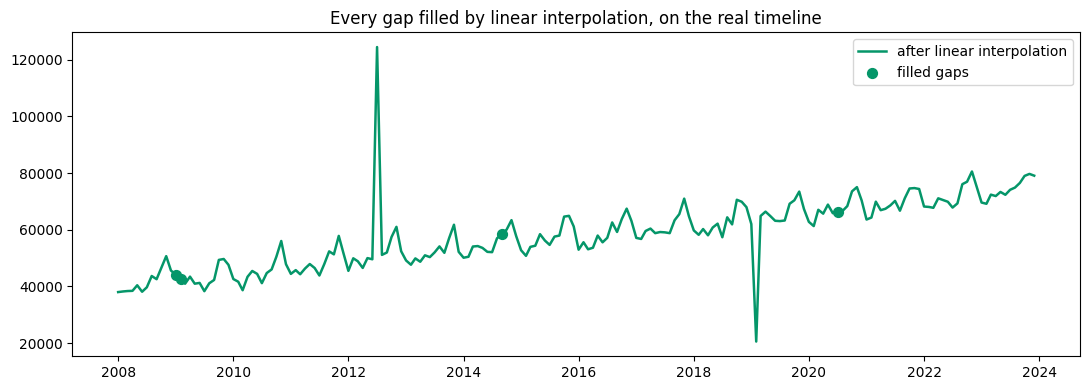

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
original_missing = pd.read_csv(DATA_PATH, parse_dates=["month"]).set_index("month")["revenue"]
ax.plot(df.index, df["revenue"], color="#059669", lw=1.8, label="after linear interpolation")
ax.scatter(original_missing.index[original_missing.isna()], df["revenue"][original_missing.isna()],
           color="#059669", zorder=5, s=50, label="filled gaps")
ax.set_title("Every gap filled by linear interpolation, on the real timeline")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
df["revenue"].isna().sum()

np.int64(0)

> **Side note:** linear interpolation is basically a moving average (explained in Section 5) that only looks at
> one neighbor on each side. Both ideas do the same thing — average nearby values — just for different purposes.


## 4. Finding anomalies

**Definition**: a value that's way off from the rest of the series. Sometimes it's a real, rare event. In
business data, it's more often just a mistake made while entering the data.

**How to spot them**: plot a histogram of all the values. An anomaly shows up as a bar sitting off on its own,
separate from the rest.


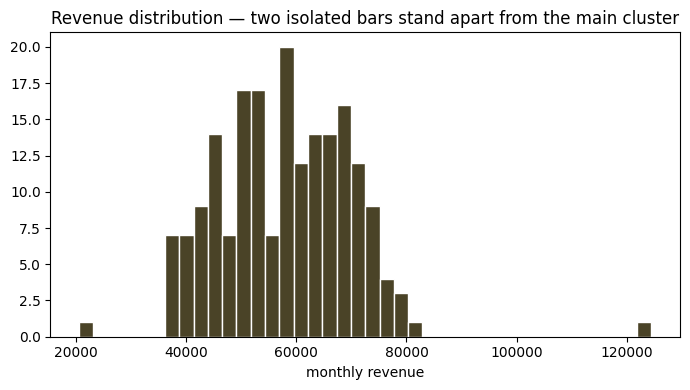

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(df["revenue"], bins=40, color="#4a4327", edgecolor="white")
plt.title("Revenue distribution — two isolated bars stand apart from the main cluster")
plt.xlabel("monthly revenue")
plt.tight_layout()
plt.show()

**How to fix them — percentile clipping.** Instead of deleting the row (which would bring back the timeline-gap
problem from Section 3), cap any extreme value at a chosen cutoff.

- A common starting point: cap values above the 95th percentile and below the 5th percentile.
- This cutoff isn't a fixed rule — you have to try it and adjust. Too strict, and it also cuts off real festive
  peaks that aren't mistakes. Too loose, and the real anomalies survive.
- In this data, 95th/5th turns out too strict — it also clips real festive-season highs. Using 98th/2nd instead
  only removes the two actual mistakes.


In [9]:
lower, upper = df["revenue"].quantile([0.02, 0.98])
print(f"Clipping bounds (2nd/98th percentile): {lower:,.0f} – {upper:,.0f}")

df["revenue_clean"] = df["revenue"].clip(lower=lower, upper=upper)
df.loc[[df.index[54], df.index[133]], ["revenue", "revenue_clean"]]

Clipping bounds (2nd/98th percentile): 38,300 – 79,021


,revenue,revenue_clean
month,,
2012-07-01,124488.50,79020.6144
2019-02-01,20535.79,38299.7892


Both mistakes get pulled back down to the cutoff value. Every normal month, including the genuinely high
festive-season months, stays exactly as it was.


## 5. Moving averages

A moving average smooths out short-term noise. At each point, it averages the last `m` values:

$$
\hat{y}_t = \frac{y_{t-1} + y_{t-2} + \cdots + y_{t-m}}{m}
$$

- **Simple Moving Average (SMA)**: every value in the window counts equally. A small window barely smooths
  anything. A large window smooths so much that it can flatten out real changes, not just noise.
- **Weighted Moving Average (WMA)**: recent values count more than older ones, so it reacts faster to real
  changes than a plain SMA does.
- **Centered Moving Average**: averages `n` values before the point *and* `n` values after it. This needs data
  from the future relative to that point, so it can't be used for forecasting — but it's great for looking back
  and understanding data you already have, which is exactly what we're doing here.

**One downside of a normal (backward-looking) SMA: it lags behind.** A real peak in the data shows up later in
the smoothed line than it actually happened, because the average is still counting the months leading up to it.


In [10]:
window = 12
df["sma_backward"] = df["revenue_clean"].rolling(window=window).mean()
df["sma_centered"] = df["revenue_clean"].rolling(window=window, center=True).mean()

weights = np.arange(1, window + 1)
df["wma"] = df["revenue_clean"].rolling(window=window).apply(
    lambda x: np.dot(x, weights) / weights.sum(), raw=True
)

df[["revenue_clean", "sma_backward", "sma_centered", "wma"]].tail(6)

,revenue_clean,sma_backward,sma_centered,wma
month,,,,
2023-07-01,74097.7100,73280.791200,74275.659067,72956.458174
2023-08-01,74884.9200,73745.282867,NaN,73203.247221
2023-09-01,76528.6800,73782.342867,NaN,73631.462164
2023-10-01,79005.5700,73953.872867,NaN,74435.035569
2023-11-01,79020.6144,73953.872867,NaN,75214.534267
2023-12-01,79020.6144,74275.659067,NaN,75994.032964


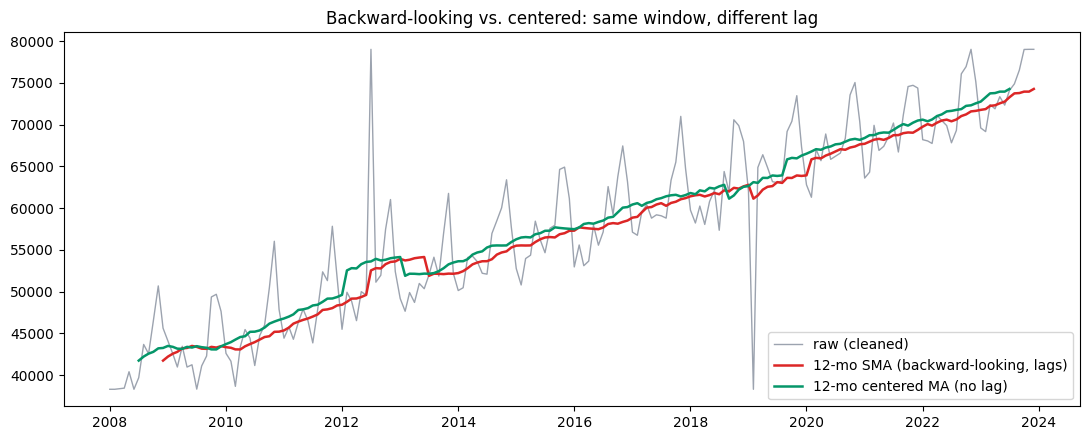

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df.index, df["revenue_clean"], color="#9ca3af", lw=1, label="raw (cleaned)")
ax.plot(df.index, df["sma_backward"], color="#DC2626", lw=1.8, label="12-mo SMA (backward-looking, lags)")
ax.plot(df.index, df["sma_centered"], color="#059669", lw=1.8, label="12-mo centered MA (no lag)")
ax.set_title("Backward-looking vs. centered: same window, different lag")
ax.legend()
plt.tight_layout()
plt.show()

The red line (backward-looking) lags behind the green line (centered) at every turn — same 12-month window, same
data. The difference is that the backward-looking version only ever looks at months that already happened.


## 6. Trend

**Definition**: the long-term direction of the data, once you smooth away the noise and the yearly ups and
downs. A trend isn't permanent — something that's been rising for 10 years can flatten out or reverse. It's also
different from seasonality, since it doesn't repeat on a fixed schedule.

Two ways to estimate the trend:

1. **Centered moving average** — we already calculated this above (`sma_centered`), using a 12-month window
   since the data is monthly. It smooths out both the noise and the yearly pattern, leaving just the direction.
2. **Linear regression** — fit a straight line, $\hat{y}_{t} = m \cdot t + c$, through the series. This gives you
   one number (the slope, `m`) that says how fast revenue is growing per month, instead of a smoothed curve.


In [12]:
t = np.arange(len(df))
valid = df["sma_centered"].notna()
m, c = np.polyfit(t[valid], df["sma_centered"][valid], 1)
df["trend_linear"] = m * t + c

print(f"Linear trend: revenue growing by ~₹{m:,.0f} per month")

Linear trend: revenue growing by ~₹175 per month


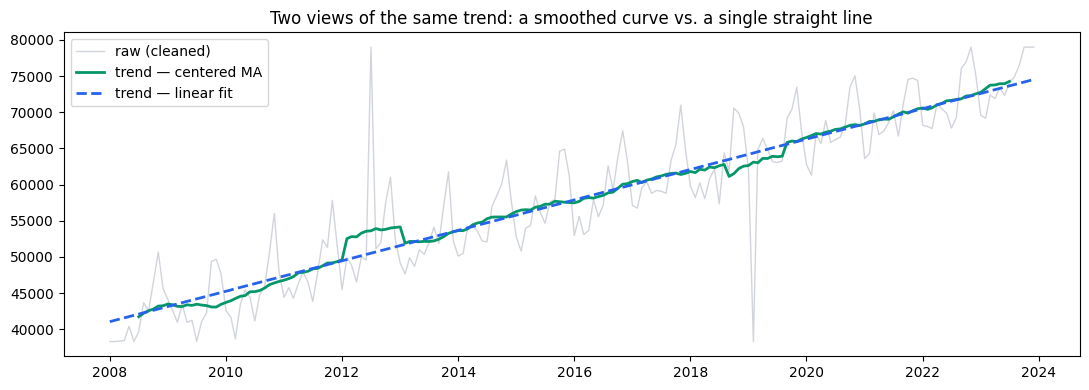

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["revenue_clean"], color="#d1d5db", lw=1, label="raw (cleaned)")
ax.plot(df.index, df["sma_centered"], color="#059669", lw=2, label="trend — centered MA")
ax.plot(df.index, df["trend_linear"], color="#2563eb", lw=2, ls="--", label="trend — linear fit")
ax.set_title("Two views of the same trend: a smoothed curve vs. a single straight line")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Seasonality

**Definition**: a pattern that repeats on a fixed, known schedule tied to the calendar — like a festive season,
a weather pattern, or a fiscal quarter. Not every up-and-down pattern counts as seasonality. Birth rates go up
and down too, but not on a fixed calendar schedule, so they aren't usually called "seasonal."

**How to pull it out of the data**: first subtract the trend from the raw series. What's left still has noise
and seasonality mixed together. Then group by calendar period — average all the Januaries together, all the
Februaries together, and so on. Since the noise is random, it mostly cancels out when averaged, leaving just the
seasonal effect for each month.


In [14]:
df["detrended"] = df["revenue_clean"] - df["sma_centered"]
seasonal_factors = df.groupby(df.index.month)["detrended"].mean()
seasonal_factors.index.name = "month"
seasonal_factors.round(0)

month
1    -2907.0
2    -4714.0
3    -1877.0
4    -1699.0
5     -630.0
6    -1630.0
7     -651.0
8     -378.0
9     1041.0
10    4814.0
11    7545.0
12    2261.0
Name: detrended, dtype: float64

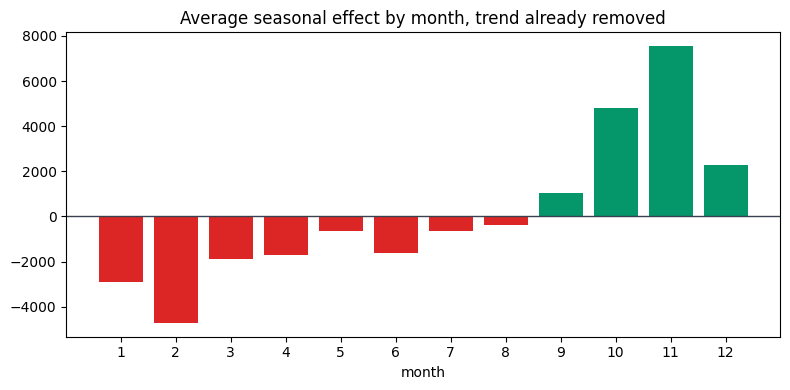

In [15]:
plt.figure(figsize=(8, 4))
colors = ["#DC2626" if v < 0 else "#059669" for v in seasonal_factors.values]
plt.bar(seasonal_factors.index, seasonal_factors.values, color=colors)
plt.axhline(0, color="#374151", lw=1)
plt.xticks(seasonal_factors.index)
plt.title("Average seasonal effect by month, trend already removed")
plt.xlabel("month")
plt.tight_layout()
plt.show()

October and November come out clearly positive (the festive season), while the mid-year months sit below zero.
This matches the seasonal pattern we built into the synthetic data — and we found it purely from the numbers,
without being told where to look.


## 8. Putting it together — full decomposition

$$
y(t) = b(t) + s(t) + e(t)
$$

Here, $b(t)$ is the trend, $s(t)$ is the seasonality, and $e(t)$ is the residual — whatever is left over once
you subtract trend and seasonality from the real data:

$$
e(t) = y(t) - b(t) - s(t)
$$

A good decomposition leaves a residual that is small, centered around zero, and has no obvious pattern of its
own. If the residual still looks structured, it means the trend or seasonality wasn't fully captured. The
`statsmodels` library can do all of this for you in one step:


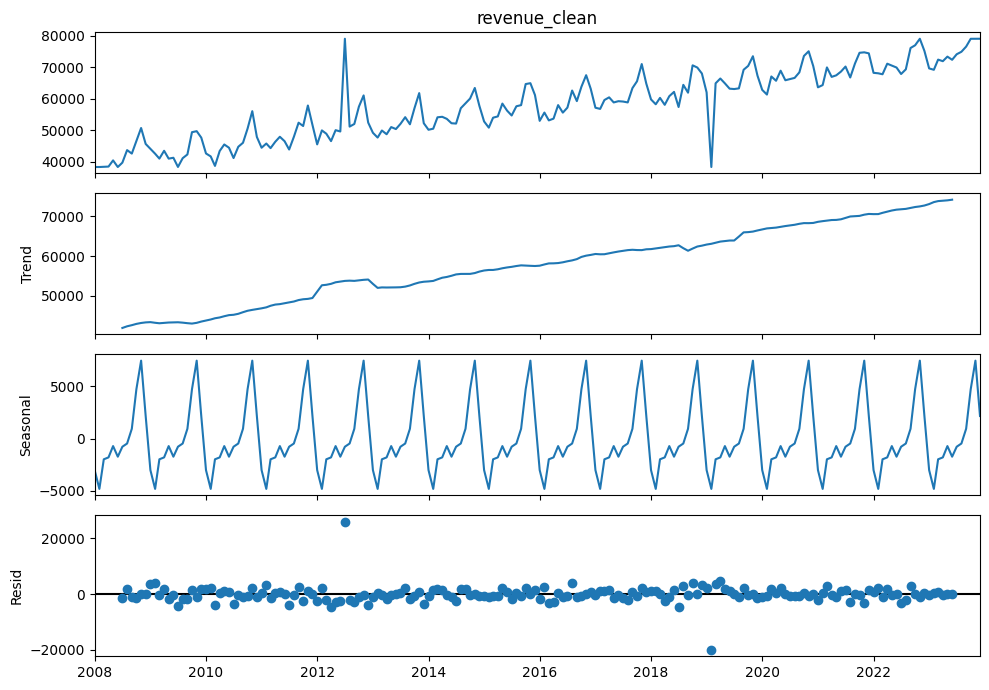

In [16]:
result = seasonal_decompose(df["revenue_clean"], model="additive", period=12)

fig = result.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

In [17]:
resid = result.resid.dropna()
print(f"Residual mean:  {resid.mean():,.1f}")
print(f"Residual range: {resid.min():,.0f} to {resid.max():,.0f}")
print(f"As a share of typical revenue: {resid.std() / df['revenue_clean'].mean():.1%}")

Residual mean:  4.9
Residual range: -19,961 to 26,027
As a share of typical revenue: 5.3%


The residual's average is close to zero, and its spread is small compared to typical revenue. This means trend
and seasonality together explain most of what's happening in the data, and what's left over really does look
like plain noise rather than a pattern we missed.


## 9. Summary — revision cheat sheet

- **Time series**: a timestamp plus a value, where the order matters. Fill gaps instead of dropping them, since
  most methods need every time period present.
- **Missing values**: interpolation (drawing a line between the points before and after a gap) is usually better
  than a flat mean or zero fill, because it accounts for what's actually happening around that gap.
- **Anomalies**: spot them with a histogram, fix them by capping (clipping) instead of deleting rows. The cutoff
  percentile needs to be tuned by eye, not fixed in stone.
- **Moving average**: $\hat{y}_t = \frac{1}{m}\sum y_{t-i}$ — average of the last `m` values. A backward-looking
  version lags behind real turning points. A centered version doesn't lag, but needs future data, so it's for
  understanding data you already have, not for forecasting.
- **Trend**: the long-term direction. Estimate it with a centered moving average (a smoothed curve) or linear
  regression (a single slope number).
- **Seasonality**: a pattern that repeats on a fixed calendar schedule. Find it by removing the trend, then
  averaging what's left by calendar period.
- **Decomposition**: $y(t) = b(t) + s(t) + e(t)$ — split the data into trend, seasonality, and residual. A small,
  centered, pattern-free residual means trend and seasonality explain most of the data.

**See it applied to forecasting:** [Time Series — Forecasting](../time-series-forecasting/notes.ipynb) picks up
this exact cleaned series and uses it to actually predict future months — baselines, moving-average and
exponential-smoothing forecasts, and how to check a forecast is stationary enough for ARIMA-style models.
